In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets

In [2]:
file_path = r"C:\Users\husna\OneDrive\Documents\bsc-4th-ca-2-data-visualisation-and-communication-Husnain-Yaqoob\Online Retail.xlsx"
df = pd.read_excel(file_path)
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


# now that i have loaded the dataset i have  checked  the structure of the dataset to understand it's types,missing value patterns and the overall schema

## Missing values Check will be done from here on

In [5]:
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# from the above output we can see that labels Description and CustomerID have missing values rest of the dataset is completely fine

In [6]:
df = df.dropna(subset=["Description"])
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

Rows with missing product descriptions were removed because product analysis requires a valid Description. These rows were few and removing them improves data quality without affecting overall results.

In [7]:
print("Duplicate rows found:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates removed. New dataset shape:", df.shape)


Duplicate rows found: 5268
Duplicates removed. New dataset shape: (535187, 8)


 A total of 5,268 duplicate rows were found in the dataset. Duplicate transaction lines can artificially inflate sales figures and distort analysis, so they were removed. After dropping duplicates, the cleaned dataset now contains 535,187 unique records, ensuring that each transaction is counted only once.

In [8]:
# Remove cancelled invoices (InvoiceNo starting with 'C')
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove negative quantities i-e returns
df = df[df["Quantity"] > 0]

# Remove zero or negative prices i-e wrong prices
df = df[df["UnitPrice"] > 0]

df.shape


(524878, 8)

Invoices beginning with “C” represent cancelled or refunded orders and are not  completed sales were removed.
Negative quantities indicate returns, and zero or negative prices are invalid entries, so these were also filtered out.
After removing these records, the dataset now contains 524,878 valid sales transactions, providing a clean foundation for accurate analysis.

# conversion required for cleaning

In [9]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"].head()


0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

InvoiceDate was converted to a proper datetime format so that time-based analysis (such as daily or monthly sales trends) can be performed accurately. This also enables date filtering later in the interactive dashboard.


Now as per assignment requirement we need to add  variables that could be best suited to this dataset i am going with totalprice and DayofWeek  options


In [10]:
# Revenue per line item
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Extract weekday name
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

df[["Quantity", "UnitPrice", "TotalPrice", "DayOfWeek"]].head()


,Quantity,UnitPrice,TotalPrice,DayOfWeek
0,6,2.55,15.30,Wednesday
1,6,3.39,20.34,Wednesday
2,8,2.75,22.00,Wednesday
3,6,3.39,20.34,Wednesday
4,6,3.39,20.34,Wednesday


Two new variables were added to enhance the analysis:
TotalPrice: Calculated as Quantity × UnitPrice, this represents the revenue for each transaction line and is useful for sales and product performance analysis.
DayOfWeek: Extracted from InvoiceDate to show the weekday of each transaction, helping identify purchasing patterns across the week.

# EDA part will be as follow

In this section I will explore the cleaned Online Retail dataset to analyze key patterns in sales behaviour, product performance, customer activity, and country-level trends. The Multiple visualisations are used to summarise the data, highlight trends, and support business decision-making.

In [11]:
df.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,524878.000000,524878,524878.000000,392692.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,15287.843865,20.275399
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,3.900000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,9.920000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,156.280031,NaN,36.093028,1713.539549,271.693566


Basic descriptive statistics help provide an overview of the numerical variables in the dataset.


In [ ]:
import matplotlib

The first visualization i have used is a horizontal bar chart  to compare the total revenue of the top 10 products. Bar charts are effective for ranking categorical data.

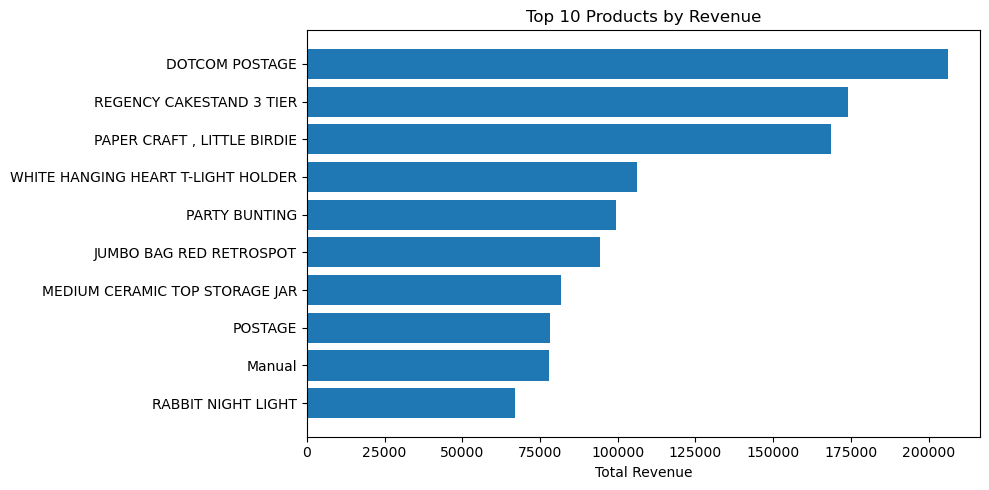

In [12]:
top_products = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(top_products.index[::-1], top_products.values[::-1])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.tight_layout()
plt.show()


The chart shows that revenue is heavily concentrated in a few key products. ‘DOTCOM POSTAGE’ generates the highest revenue, followed by several popular decorative items such as cake stands, craft products, and T-light holders. This indicates that both postage charges and select novelty items are major contributors to overall sales, making them important products for stock management and promotional focus.

# normal bar plot

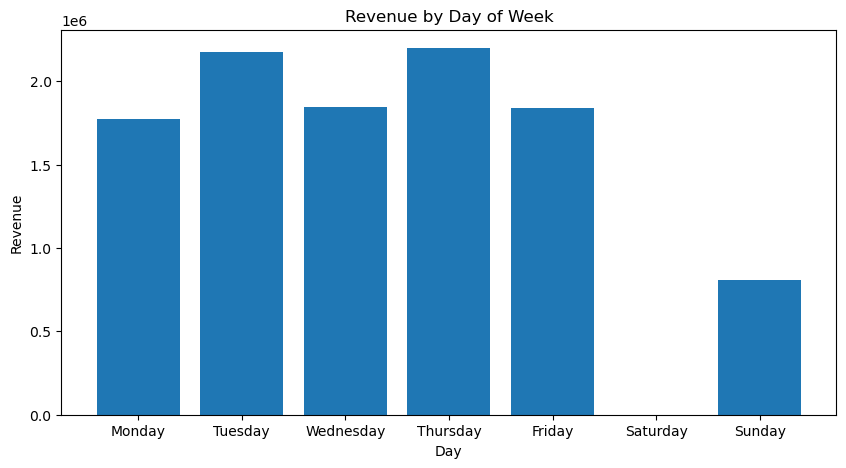

In [18]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

sales_by_day = df.groupby("DayOfWeek")["TotalPrice"].sum().reindex(order)

plt.figure(figsize=(10,5))
plt.bar(sales_by_day.index, sales_by_day.values)
plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.show()


The chart shows that Tuesday and Thursday generate the highest revenue, indicating strong mid-week purchasing behaviour. Monday, Wednesday, and Friday also show steady sales, while Sunday has significantly lower revenue, suggesting reduced customer activity at the end of the week. This pattern highlights that most sales occur on weekdays, especially mid-week.

# The line chart is showing monthly total revenue which helps in identifying seasonal patterns and growth trends.

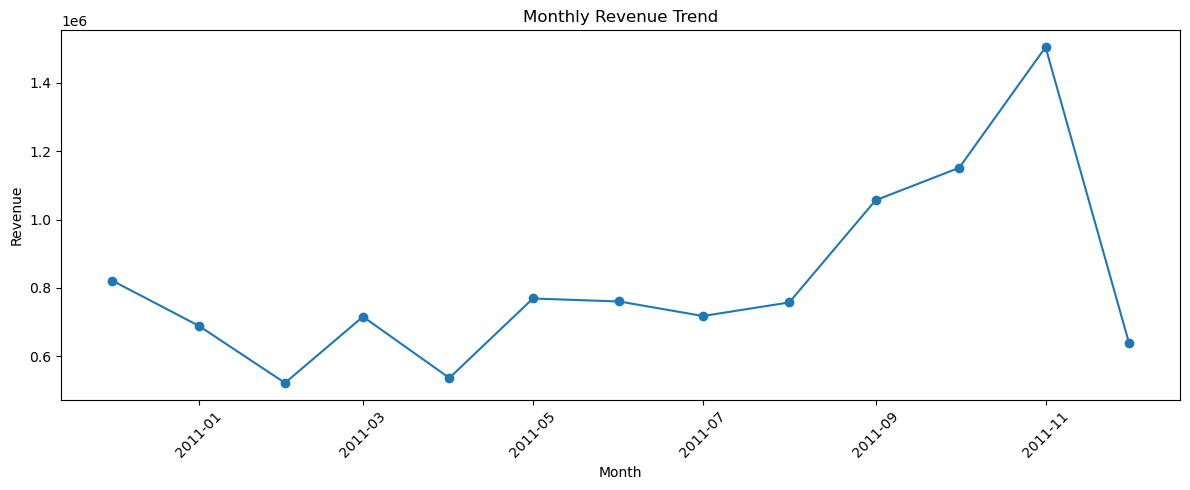

In [21]:
monthly_sales = df.groupby(df["InvoiceDate"].dt.to_period("M"))["TotalPrice"].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


This reveals peak and low-performing months, useful for planningstock and promotions.

# Heatmap revenue by day while checking peak and low rush hours

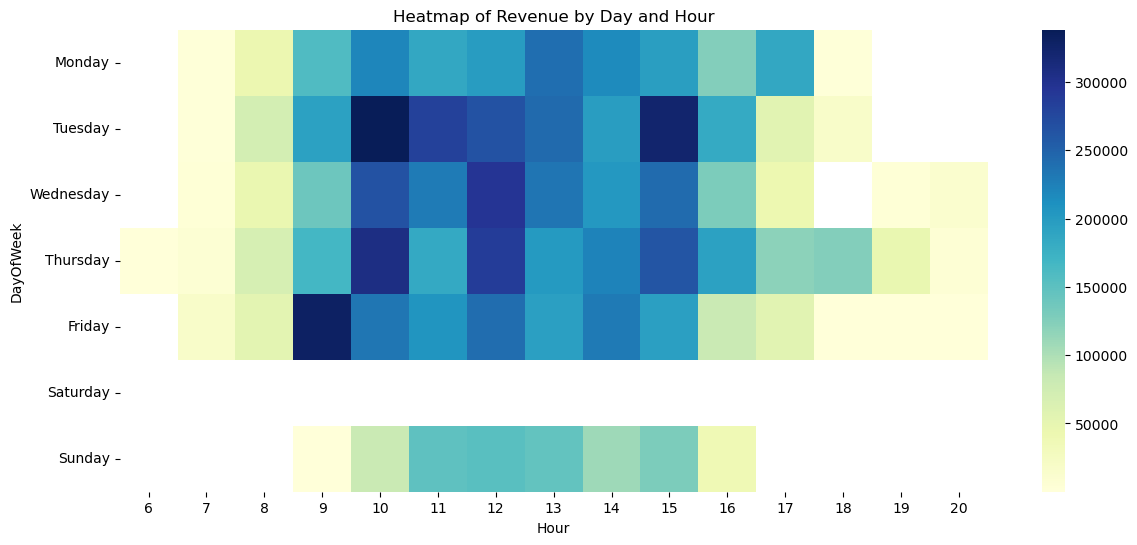

In [25]:
df["Hour"] = df["InvoiceDate"].dt.hour

heatmap_data = df.pivot_table(
    values="TotalPrice",
    index="DayOfWeek",
    columns="Hour",
    aggfunc="sum"
)

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
heatmap_data = heatmap_data.reindex(order)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Heatmap of Revenue by Day and Hour")
plt.show()


The heatmap reveals clear patterns in customer purchasing behaviour. Mid-week days, especially Tuesday to Thursday, show consistently higher revenue, with noticeable peaks during morning to early afternoon hours. Activity drops significantly in the late evening and on weekends, indicating that customers are more active during standard working hours on weekdays. This pattern can help in planning staffing, promotions, and operational scheduling.

# Histogram to view customer purchase frequency

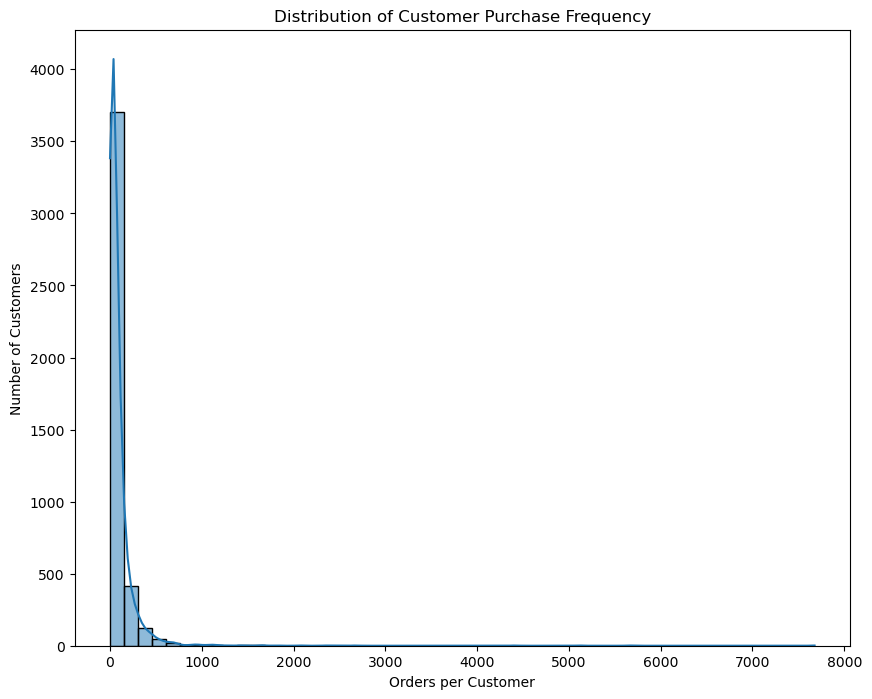

In [31]:
customer_counts = df["CustomerID"].value_counts()

plt.figure(figsize=(10,8))
sns.histplot(customer_counts, bins=50, kde=True)
plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Orders per Customer")
plt.ylabel("Number of Customers")
plt.show()


This shows that most customers make only a small number of purchases, while a much smaller group makes a higher number of repeat orders. This indicates that the business relies heavily on a large base of occasional buyers, with a minority of loyal customers contributing disproportionately to overall activity. Understanding and targeting these repeat customers could help improve retention and revenue.

# Count plot for the most common purchase quantities

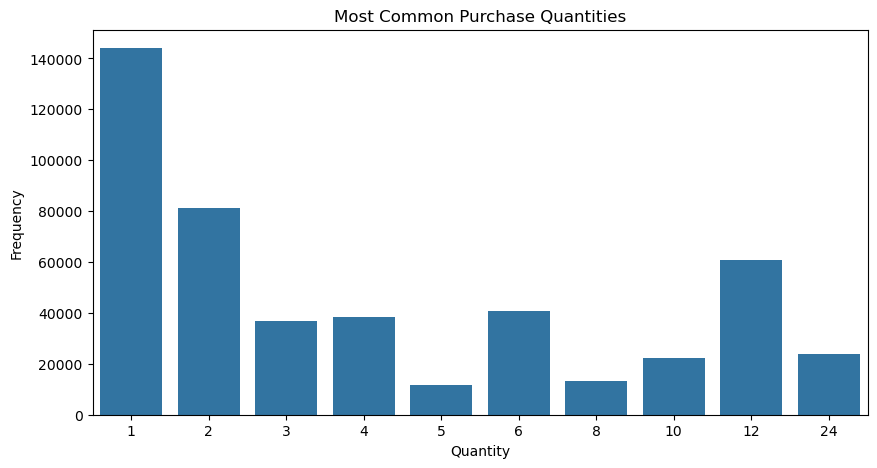

In [32]:
quantity_counts = df["Quantity"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=quantity_counts.index, y=quantity_counts.values)
plt.title("Most Common Purchase Quantities")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()


The count plot shows that customers most frequently purchase small quantities, with values like 1, 2, 6, and 12 units appearing most often. This indicates that the business primarily handles small retail-style orders, with occasional larger bulk purchases. Understanding these typical order sizes can help with inventory planning and packaging decisions.

# Now the dashboard part will be done 

In [12]:
# Dropdown for selecting country
country_dropdown = widgets.Dropdown(
    options=["All"] + sorted(df["Country"].unique().tolist()),
    value="All",
    description="Country:",
    layout=widgets.Layout(width="250px")
)

# Slider for selecting minimum revenue
min_revenue_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=int(df["TotalPrice"].max()),
    step=50,
    description="Min Revenue:",
    continuous_update=False,
    layout=widgets.Layout(width="350px")
)

# Date range slider for filtering on InvoiceDate
date_range_slider = widgets.SelectionRangeSlider(
    options=pd.date_range(df["InvoiceDate"].min(), df["InvoiceDate"].max(), freq='D'),
    index=(0, len(pd.date_range(df["InvoiceDate"].min(), df["InvoiceDate"].max())) - 1),
    description="Date Range:",
    layout=widgets.Layout(width="600px")
)


the filter functions are as follows

In [13]:
def filter_data(country, min_revenue, date_range):
    """
    Filters the dataset based on:
    - Country selection
    - Minimum revenue threshold
    - Date range selection
    """

    filtered = df.copy()

    # Filter by country
    if country != "All":
        filtered = filtered[filtered["Country"] == country]

    # Filter by revenue threshold
    filtered = filtered[filtered["TotalPrice"] >= min_revenue]

    # Filter by date range
    filtered = filtered[
        (filtered["InvoiceDate"] >= date_range[0]) &
        (filtered["InvoiceDate"] <= date_range[1])
    ]

    return filtered
